In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

In [2]:
# check for gpu
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device:{device}")

Using device:cuda


In [3]:
# set the random state
torch.manual_seed(42)

In [4]:
df=pd.read_csv(r"E:\Downloads\training_sheets\fashion-mnist_train.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


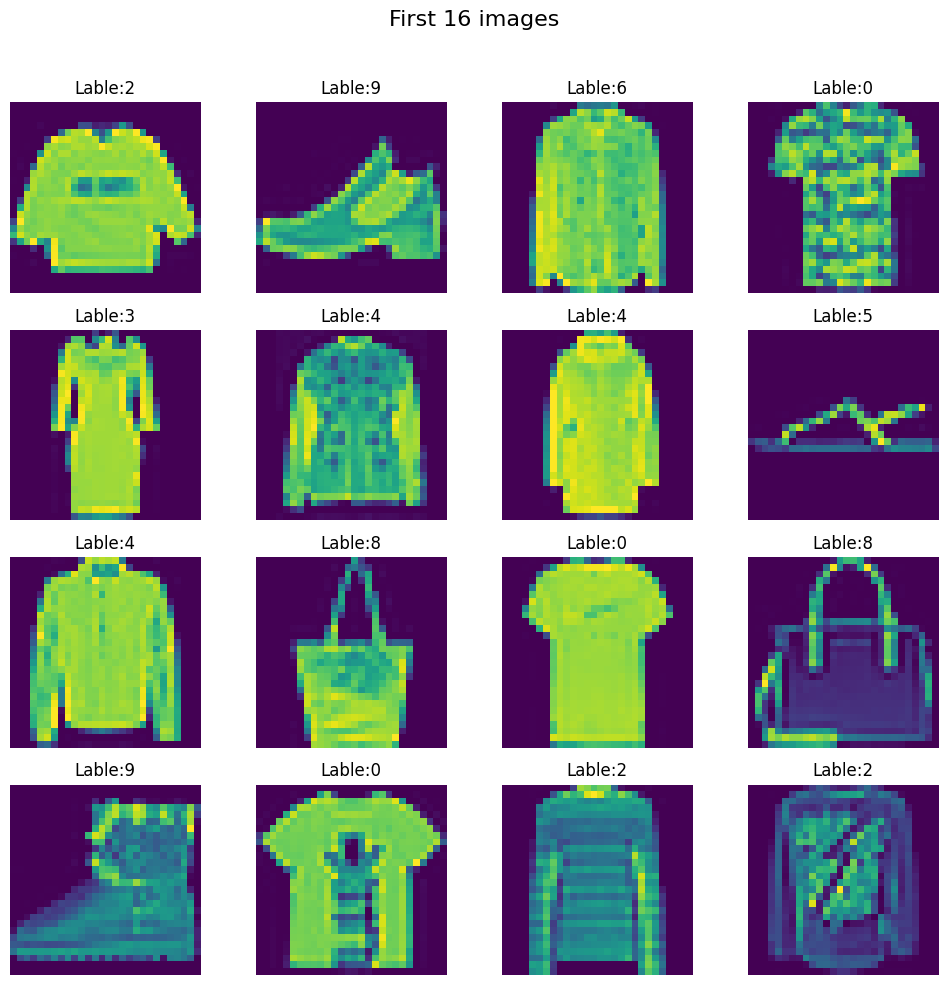

In [5]:
# create grid images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 images",fontsize=16)

#plot the 1st 16 images
for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Lable:{df.iloc[i,0]}")

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [6]:
# train test split
X=df.iloc[:,1:].values
y=df.iloc[:,0].values
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
# Transformations required for vgg16
from torchvision.transforms import transforms

custom_transform=transforms.Compose([
    transforms.Resize(256),    # ---------> it reshapes into (3,256,256)
    transforms.CenterCrop(224), # ---------> it crops at centre (3,224,224)
    transforms.ToTensor(),      #-----------> it converts the to tensor and even scales it
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])  # it is use to nomalize
])

In [8]:
class CustomDataset(Dataset):
    def __init__(self,features,labels,transform):
        self.features=features
        self.labels=labels
        self.transform=transform

    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):

        #resize to (28,28)
        image=self.features[index].reshape(28,28)

        # change datatype to uint8
        image=image.astype(np.uint8)

        # change b&w to color
        image = np.stack([image, image, image], axis=-1)

        # convert array to PIL IMage
        image=Image.fromarray(image)

        # apply transforms
        image=self.transform(image)

        return image,torch.tensor(self.labels[index],dtype=torch.long)

In [9]:
train_dataset=CustomDataset(X_train,y_train,transform=custom_transform)
test_dataset=CustomDataset(X_test,y_test,transform=custom_transform)

In [10]:
train_dataloader=DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_dataloader=DataLoader(test_dataset,batch_size=32,shuffle=True,pin_memory=True)

In [11]:
# Fetch the Pretrained model
from torchvision import models

vgg16=models.vgg16(pretrained=True)

d:\AI\PyTorch\torch_gpu\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\AI\PyTorch\torch_gpu\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [12]:
vgg16.features

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [13]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [14]:
for param in vgg16.features.parameters():
    param.requires_grad=False

In [15]:
vgg16.classifier=nn.Sequential(
    nn.Linear(25088,1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024,512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512,10)
)

In [16]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [17]:
vgg16=vgg16.to(device) 

In [18]:
lr=0.0001
epochs=10

In [19]:
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(vgg16.classifier.parameters(),lr=lr)

In [20]:
# Training Loop
for epoch in range(epochs):
    total_epoch_loss=0
    for batch_features,batch_labels in train_dataloader:
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)

        #forward
        outputs=vgg16.forward(batch_features)

        # cal loss
        loss=criterion(outputs,batch_labels)

        #back pass
        optimizer.zero_grad()
        loss.backward()

        #update grads
        optimizer.step()

        total_epoch_loss+=loss.item()

    avg_loss=total_epoch_loss/len(train_dataloader)
    print(f"Epoch:{epoch+1},Loss:{avg_loss}")
    

Epoch:1,Loss:0.3665389111364881
Epoch:2,Loss:0.2172282940062384
Epoch:3,Loss:0.16812146477572
Epoch:4,Loss:0.13093499588252355
Epoch:5,Loss:0.10490221136249601
Epoch:6,Loss:0.0820645670912927
Epoch:7,Loss:0.06882072645953546
Epoch:8,Loss:0.056115529969727504
Epoch:9,Loss:0.045480326844347774
Epoch:10,Loss:0.042447224212553314


In [21]:
vgg16.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [23]:
#evaluation code
total=0
correct=0

with torch.no_grad():
    for batch_features,batch_labels in test_dataloader:
        #move data to gpu
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)
        outputs=vgg16(batch_features)
        _,predicted=torch.max(outputs,1)
        total+=batch_labels.shape[0]
        correct+=(predicted==batch_labels).sum().item()

    print(correct/total)

0.92675
